# Exploratory Data Analysis — Credit Risk Scoring

Goal: understand the target distribution, feature relationships with default,
and identify data quality issues before any modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../data/application_data.csv")
df.shape

(12000, 16)

In [2]:
df.head()

,SK_ID_CURR,TARGET,AGE,AMT_INCOME_TOTAL,AMT_CREDIT,DURATION_MONTHS,EMPLOYMENT_YEARS,CHECKING_STATUS,SAVINGS_STATUS,PURPOSE,HOUSING,NUM_DEPENDENTS,EXISTING_CREDITS,DELINQUENCIES_2YR,DEBT_TO_INCOME,CREDIT_UTILIZATION
0,100001,0,25,106598.07,18858.62,24,3.4,negative,unknown,furniture,own,0,3,1,0.1769,0.1589
1,100002,0,58,83606.20,500.00,36,1.0,0_to_200,low,electronics,rent,4,0,1,0.0060,0.3010
2,100003,1,53,94069.58,5279.48,24,3.8,0_to_200,medium,electronics,rent,1,2,0,0.0561,0.6504
3,100004,0,42,52271.28,7738.89,48,1.5,no_account,unknown,renovation,own,0,2,1,0.1480,0.2772
4,100005,0,42,49912.89,21650.51,18,0.7,negative,unknown,furniture,with_parents,1,4,0,0.4338,0.1879


## Target distribution (class imbalance)

Default rate: 16.83%


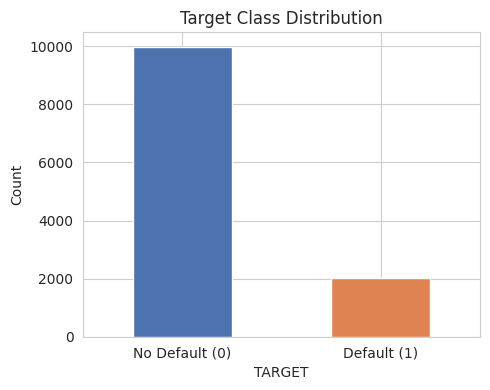

In [3]:
default_rate = df["TARGET"].mean()
print(f"Default rate: {default_rate:.2%}")

fig, ax = plt.subplots(figsize=(5,4))
df["TARGET"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452"])
ax.set_xticklabels(["No Default (0)", "Default (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

This is a moderately imbalanced problem (~17% positive class) — typical for
credit risk. Accuracy alone would be misleading here (a model predicting
"no default" for everyone would already be ~83% "accurate"), which is why
AUC, KS, and Gini are used for evaluation instead.

## Missing values check

In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: float64)

## Numeric feature distributions by target

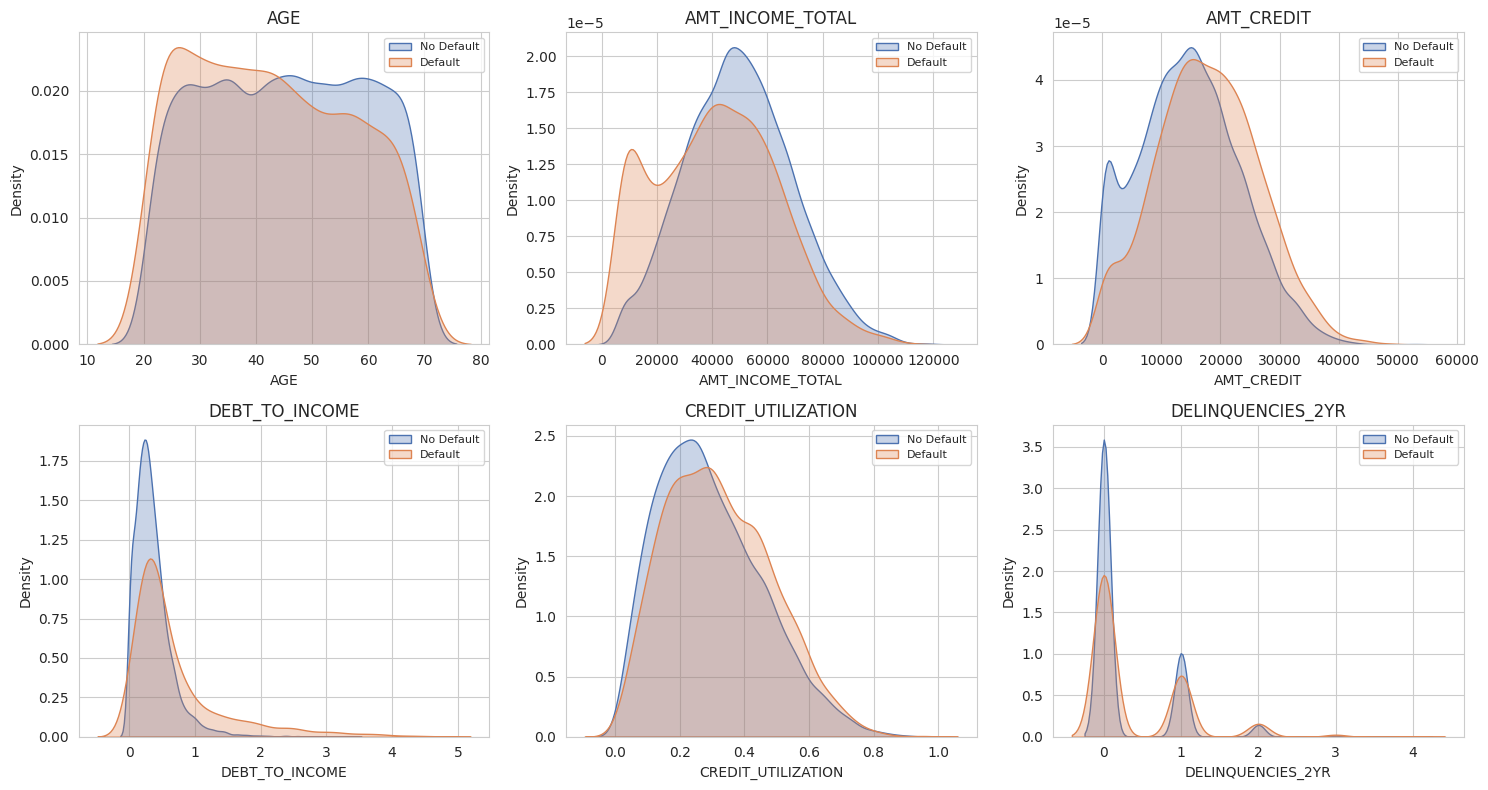

In [5]:
numeric_cols = ["AGE","AMT_INCOME_TOTAL","AMT_CREDIT","DEBT_TO_INCOME","CREDIT_UTILIZATION","DELINQUENCIES_2YR"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    for t, label, color in [(0, "No Default", "#4C72B0"), (1, "Default", "#DD8452")]:
        sns.kdeplot(df.loc[df.TARGET==t, col], ax=ax, label=label, color=color, fill=True, alpha=0.3)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

`DEBT_TO_INCOME` and `CREDIT_UTILIZATION` show the clearest separation
between defaulters and non-defaulters — consistent with the Information
Value ranking computed later in the modeling notebook/script.

## Categorical features vs default rate

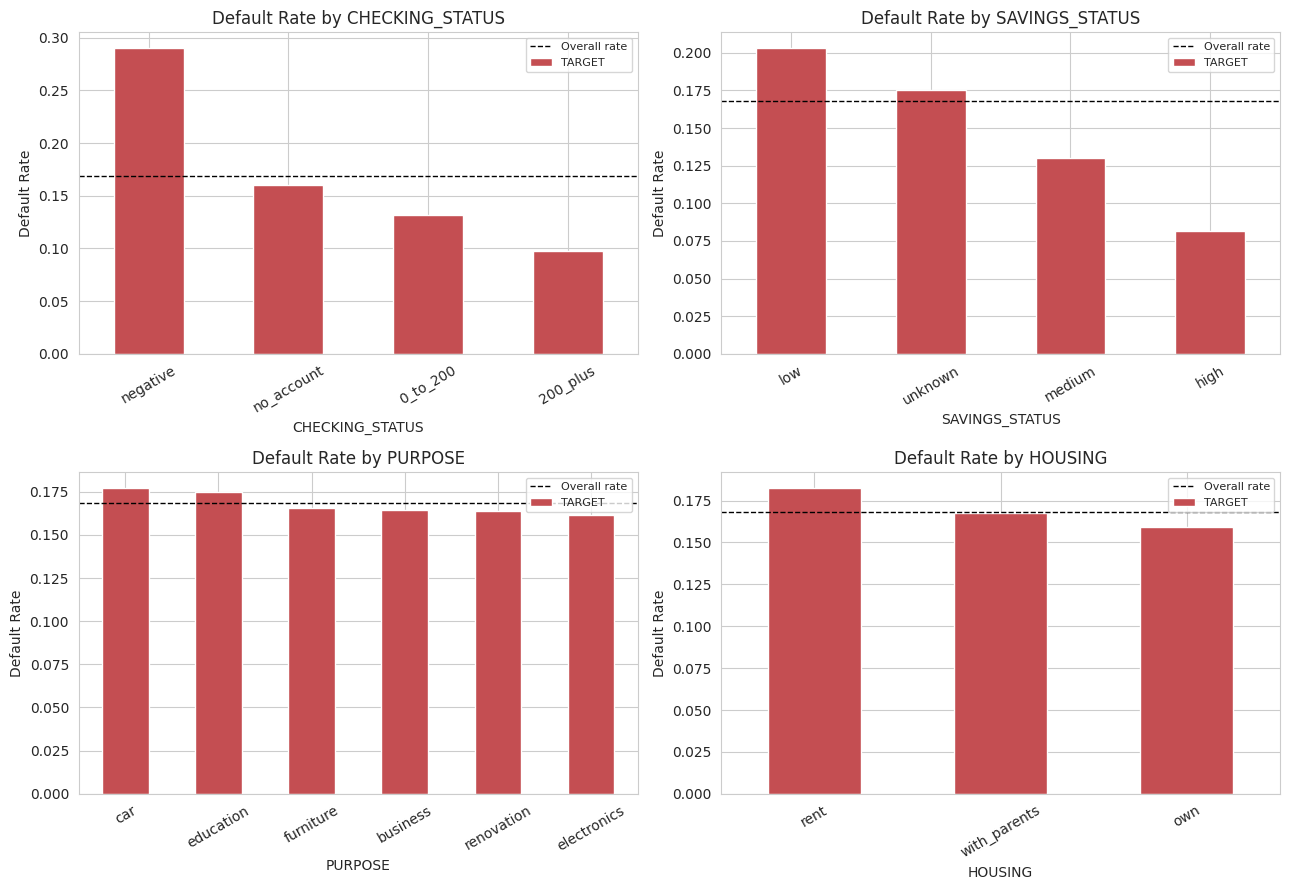

In [6]:
cat_cols = ["CHECKING_STATUS","SAVINGS_STATUS","PURPOSE","HOUSING"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#C44E52")
    ax.axhline(default_rate, color="black", linestyle="--", linewidth=1, label="Overall rate")
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

`CHECKING_STATUS = negative` and `SAVINGS_STATUS = unknown/low` both show
default rates well above the portfolio average — exactly the kind of signal
WOE binning is designed to capture cleanly for a logistic scorecard.

## Correlation among numeric features


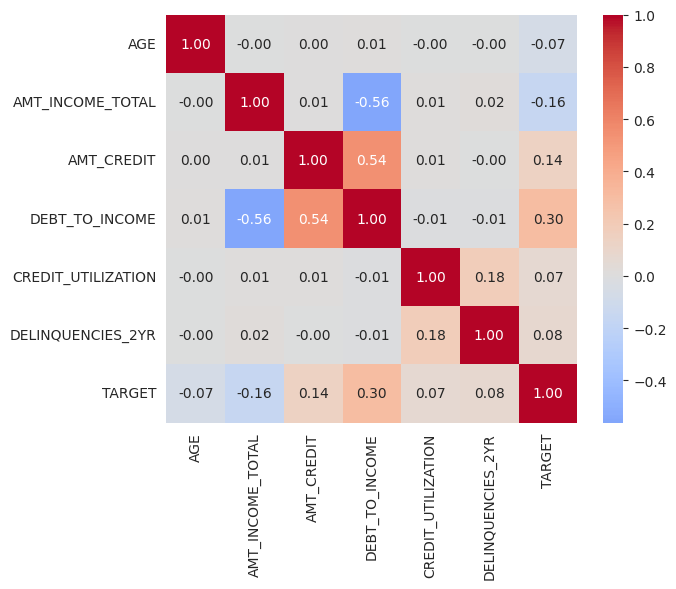

In [7]:
corr = df[numeric_cols + ["TARGET"]].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

## Takeaways for modeling

- Target is imbalanced (~17% default) -> use AUC/KS/Gini, not accuracy; consider class weighting for the tree model.
- `DEBT_TO_INCOME`, `CREDIT_UTILIZATION`, `CHECKING_STATUS`, and `SAVINGS_STATUS` are the strongest signals and should be prioritized in feature engineering.
- No missing values in this synthetic set, but the WOE pipeline in `src/features.py` handles missing bins gracefully in case the real Kaggle data is substituted in.
- Proceed to `src/features.py` (WOE/IV) and `src/train.py` (modeling) for the next stage of the pipeline.